In [6]:
!pip install catboost lightgbm xgboost wandb optuna optuna-integration

In [7]:
import os
import random
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import average_precision_score
from sklearn.model_selection import train_test_split
from scipy.optimize import minimize
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import wandb
from google.colab import drive

os.environ["WANDB_API_KEY"] = "<YOUR_WANDB_API_KEY>"

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    return seed

SEED = seed_everything(42)

def init_wandb(project_name="lead-prioritization-baseline", run_name="ensemble-baseline", config=None):
    wandb.login()
    run = wandb.init(
        project=project_name,
        name=run_name,
        config=config,
        reinit=True
    )
    return run

In [3]:
import os
if not os.path.exists('QueryPrioritizationAvito') and not os.path.exists('data'):
    !git clone https://github.com/YohanKIM-creator/QueryPrioritizationAvito.git
    os.chdir('QueryPrioritizationAvito')

from pathlib import Path
import pandas as pd

DATA_DIR = Path('data')

print("Loading data...")
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
events = pd.read_csv(DATA_DIR / "events.csv")
print(f"Loaded train: {train.shape}, test: {test.shape}, events: {events.shape}")

Cloning into 'QueryPrioritization'...
remote: Enumerating objects: 18, done.
remote: Counting objects: 100% (18/18), done.
remote: Compressing objects: 100% (15/15), done.
remote: Total 18 (delta 3), reused 18 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (18/18), 7.20 MiB | 8.49 MiB/s, done.
Resolving deltas: 100% (3/3), done.
Loading data...
Loaded train: (13694, 119), test: (4306, 118), events: (254705, 7)


# 1. Анализ признаков и Feature Engineering

### Исходные признаки датасета (train.csv / test.csv)
Исходный датасет содержит 118 признаков:
- **Метаданные лида и пользователя**: источник обращения (`lead_source`), колл-центр (`call_center`), регион (`region`), ценовой сегмент (`price_bucket`), стаж пользователя на платформе (`user_tenure_bucket`), возраст аккаунта в днях (`user_age_days`), количество предыдущих назначений (`prior_assignments_30d`).
- **Характеристики авто и продавца**: сегмент автомобиля (`car_segment`), возраст авто (`car_age_years`), логарифм пробега (`mileage_km_log`), логарифм цены (`item_price_log`), размер парка продавца (`seller_inventory_count`), процент ответов продавца за 30 дней (`seller_response_rate_30d`).
- **Контекст времени**: час назначения (`assignment_hour`), день недели (`assignment_weekday`), флаг выходного дня (`is_weekend`).
- **Готовые временные агрегаты по 6 окнам (1d, 3d, 7d, 14d, 30d, 90d)**: активные дни (`active_days_auto`), просмотры товаров (`item_views`), добавления в избранное (`item_favorites`), раскрытия деталей (`detail_expands`), свайпы фото (`photo_swipes`), просмотры страницы продавца (`seller_page_views`), поисковые запросы (`search_views`), уточнения поиска (`query_refinements`), клики по похожим авто (`similar_item_clicks`), совпадения сохраненного поиска (`saved_search_matches`), контакты продавца (`user_contacts`), открытия чатов (`chat_opens`), клики по звонкам (`call_clicks`), а также история ответов и успехов предыдущих лидов (`leadgen_prev_assigned`, `answered`, `positive`).

---

### Сконструированные признаки (Feature Engineering)

#### 1. Признаки, извлеченные из логов событий (events.csv):
- **Счетчики активностей**: `total_events` (общее число событий до момента назначения) и `event_count_<event_type>` (счетчики отдельных видов действий: просмотры, звонки, чаты).
- **Временные метрики и давность**: `days_since_last_event` (время от последнего события до назначения лида в днях), `active_duration_days` (длительность истории активности от первого до последнего события).
- **Интенсивность и плотность сессий**: `avg_hours_between_events` (средний интервал между событиями в часах) и `std_hours_between_events` (дисперсия интервалов).
- **Недавняя динамика**: `events_last_24h` и `events_last_7d` (количество действий за последние 24 часа и 7 дней до назначения).
- **Ценовой профиль**: `price_log_mean`, `price_log_max`, `price_log_std` (средняя, максимальная цена и разброс цен товаров, просмотренных пользователем).
- **Разнообразие действий**: `unique_slots` (число уникальных плейсментов) и `unique_contexts` (число уникальных контекстных цепочек).
- **Часовые флаги**: `last_event_hour` (час последнего события) и `is_weekend_assignment` (назначение в выходные).

#### 2. Относительные коэффициенты и относительная динамика:
- **Конверсии лидгена**: `leadgen_success_rate_7d`, `leadgen_success_rate_30d`, `leadgen_success_rate_90d` (доля успешных ответов), `leadgen_answer_rate_30d`, `leadgen_answer_rate_90d` (доля ответов), `leadgen_success_to_answer_rate_30d`.
- **Вовлеченность (Engagement Rates)**: `contact_to_view_rate_30d`, `contact_to_view_rate_90d`, `chat_to_view_rate_30d`, `call_to_view_rate_30d`, `detail_to_view_rate_30d`, `fav_to_view_rate_30d`.
- **Ускорение интереса (Velocity)**: `views_accel_1d_7d`, `views_accel_3d_30d`, `contacts_accel_1d_30d`, `chats_accel_1d_30d`, `calls_accel_1d_30d`, `search_accel_1d_7d` (отношения краткосрочной активности к долгосрочной).
- **Плотность активности**: `user_active_density_30d` (доля активных дней за месяц) и `active_days_ratio_30d` (доля авто-активных дней к общим активным дням).
- **Загрузка системы**: `global_daily_workload`, `region_daily_workload`, `center_daily_workload`, `source_daily_workload` (количество назначений в тот же день в разрезе всей системы, региона, колл-центра и источника).

In [8]:
def engineer_features(leads, events):
    print(f"Engineering features for {len(leads)} leads...")
    leads = leads.copy()

    # Защита от деления на 0 во избежание аномальных выбросов в гистограммах бустинга
    def safe_divide(num_col, den_col):
        return np.where(leads[den_col] > 0, leads[num_col] / leads[den_col], 0.0)

    leads['leadgen_success_rate_30d'] = safe_divide('leadgen_prev_positive_30d', 'leadgen_prev_assigned_30d')
    leads['leadgen_success_rate_90d'] = safe_divide('leadgen_prev_positive_90d', 'leadgen_prev_assigned_90d')
    leads['leadgen_success_rate_7d'] = safe_divide('leadgen_prev_positive_7d', 'leadgen_prev_assigned_7d')
    leads['leadgen_answer_rate_30d'] = safe_divide('leadgen_prev_answered_30d', 'leadgen_prev_assigned_30d')
    leads['leadgen_answer_rate_90d'] = safe_divide('leadgen_prev_answered_90d', 'leadgen_prev_assigned_90d')
    leads['leadgen_success_to_answer_rate_30d'] = safe_divide('leadgen_prev_positive_30d', 'leadgen_prev_answered_30d')

    leads['contact_to_view_rate_30d'] = safe_divide('user_contacts_30d', 'item_views_30d')
    leads['contact_to_view_rate_90d'] = safe_divide('user_contacts_90d', 'item_views_90d')
    leads['chat_to_view_rate_30d'] = safe_divide('chat_opens_30d', 'item_views_30d')
    leads['call_to_view_rate_30d'] = safe_divide('call_clicks_30d', 'item_views_30d')
    leads['detail_to_view_rate_30d'] = safe_divide('detail_expands_30d', 'item_views_30d')
    leads['fav_to_view_rate_30d'] = safe_divide('item_favorites_30d', 'item_views_30d')

    leads['views_accel_1d_7d'] = safe_divide('item_views_1d', 'item_views_7d')
    leads['views_accel_3d_30d'] = safe_divide('item_views_3d', 'item_views_30d')
    leads['contacts_accel_1d_30d'] = safe_divide('user_contacts_1d', 'user_contacts_30d')
    leads['chats_accel_1d_30d'] = safe_divide('chat_opens_1d', 'chat_opens_30d')
    leads['calls_accel_1d_30d'] = safe_divide('call_clicks_1d', 'call_clicks_30d')
    leads['search_accel_1d_7d'] = safe_divide('search_views_1d', 'search_views_7d')

    leads['user_active_density_30d'] = leads['user_active_days_30d'] / 30.0
    leads['active_days_ratio_30d'] = safe_divide('active_days_auto_30d', 'user_active_days_30d')

    leads['global_daily_workload'] = leads.groupby('assignment_date')['lead_id'].transform('count')
    leads['region_daily_workload'] = leads.groupby(['assignment_date', 'region'])['lead_id'].transform('count')
    leads['center_daily_workload'] = leads.groupby(['assignment_date', 'call_center'])['lead_id'].transform('count')
    leads['source_daily_workload'] = leads.groupby(['assignment_date', 'lead_source'])['lead_id'].transform('count')

    events_merged = events.merge(leads[['lead_id', 'assignment_ts']], on='lead_id', how='left')
    events_merged['event_ts'] = pd.to_datetime(events_merged['event_ts'])
    events_merged['assignment_ts'] = pd.to_datetime(events_merged['assignment_ts'])

    # Фильтр событий строго до момента назначения лида для защиты от утечки в будущее
    valid_events = events_merged[events_merged['event_ts'] < events_merged['assignment_ts']].copy()

    f_total_events = valid_events.groupby('lead_id').size().rename('total_events')

    f_event_types = valid_events.groupby(['lead_id', 'event_type']).size().unstack(fill_value=0)
    f_event_types.columns = [f'event_count_{col}' for col in f_event_types.columns]

    last_event = valid_events.groupby('lead_id').agg(
        event_ts=('event_ts', 'max'),
        assignment_ts=('assignment_ts', 'max')
    ).reset_index()
    last_event['days_since_last_event'] = (last_event['assignment_ts'] - last_event['event_ts']).dt.total_seconds() / 86400
    f_recency = last_event.set_index('lead_id')['days_since_last_event']

    events_sorted = valid_events.sort_values(['lead_id', 'event_ts'])
    events_sorted['time_diff'] = events_sorted.groupby('lead_id')['event_ts'].diff().dt.total_seconds() / 3600
    f_time_diff = events_sorted.groupby('lead_id')['time_diff'].agg(['mean', 'std']).fillna(0)
    f_time_diff.columns = ['avg_hours_between_events', 'std_hours_between_events']

    time_to_assignment = (valid_events['assignment_ts'] - valid_events['event_ts']).dt.total_seconds() / 86400
    valid_events['is_last_24h'] = time_to_assignment <= 1
    f_recent = valid_events.groupby('lead_id')['is_last_24h'].sum().rename('events_last_24h')

    last_event['assignment_hour'] = last_event['assignment_ts'].dt.hour
    last_event['last_event_hour'] = last_event['event_ts'].dt.hour
    last_event['is_weekend_assignment'] = last_event['assignment_ts'].dt.dayofweek >= 5
    f_time_features = last_event.set_index('lead_id')[['assignment_hour', 'last_event_hour', 'is_weekend_assignment']]

    f_price = valid_events.groupby('lead_id')['item_price_log'].agg(['mean', 'max', 'std']).fillna(0)
    f_price.columns = ['price_log_mean', 'price_log_max', 'price_log_std']

    f_diversity = valid_events.groupby('lead_id').agg(
        unique_slots=('src_slot', 'nunique'),
        unique_contexts=('ctx_seq', 'nunique')
    )

    recent_events_7d = valid_events[time_to_assignment <= 7]
    f_velocity = recent_events_7d.groupby('lead_id').size().rename('events_last_7d')

    duration_df = valid_events.groupby('lead_id')['event_ts'].agg(['min', 'max'])
    f_duration = (duration_df['max'] - duration_df['min']).dt.total_seconds() / 86400
    f_duration.name = 'active_duration_days'

    features_df = pd.concat([
        f_total_events, f_event_types, f_recency, f_price, f_diversity,
        f_velocity, f_duration, f_time_diff, f_recent, f_time_features
    ], axis=1).fillna(0)

    leads_with_features = leads.merge(features_df, on='lead_id', how='left').fillna(0)
    return leads_with_features

train_fe = engineer_features(train, events)
test_fe = engineer_features(test, events)
print("Feature engineering complete.")

Engineering features for 13694 leads...
Engineering features for 4306 leads...
Feature engineering complete.


# 2. Стратегия валидации и воспроизводимость

### Метрика и схема кросс-валидации (5-Fold GroupKFold)
Официальной метрикой задачи является **Daily Average Precision (Daily AP)**. Для каждого дня назначения (`assignment_date`) вычисляется `average_precision_score` по предсказанным вероятностям конверсии, после чего результаты усредняются по всем дням выборки.

Для корректного моделирования используется **5-Fold GroupKFold** с группировкой по дате назначения (`assignment_date`):
- **Защита от утечки контекста (таргет-лик)**: При обычном случайном K-Fold записи одного и того же дня попадают одновременно в обучение и валидацию. Модель запоминает дневную нагрузку и общий уровень конверсии конкретного дня, что ведет к завышенному валидационному скору (0.66+), который проседает на тесте. GroupKFold гарантирует, что целиком 5 валидационных фолдов представляют собой выпадающие независимые дни.
- **OOF-предсказания (Out-of-Fold)**: Модель предсказывает вероятности для каждого отложенного фолда. Оценка OOF-предсказаний по всем 16 дням дает несмещенную оценку качества ранжирования на новых датах.

---

### Подбор гиперпараметров (OOT Holdout)
Запуск 5-fold CV для каждого триала Optuna требовал бы 150 полных обучений на CPU.

Поэтому подбор гиперпараметров выполняется на временном сплите **Out-Of-Time (OOT)**: первые 12 дней используются для обучения, а последние 4 дня — для валидации. Такой OOT-сплит полностью сохраняет хронологию, исключает заглядывание в будущее и ускоряет расчеты в 5 раз. Найденные параметры сохраняются в файл `optuna_best_params_new.pkl` и автоматически подгружаются в основной цикл 5-fold CV.

---

### Воспроизводимость
- Все случайные процессы зафиксированы единым сидом (`SEED = 42`).
- Категориальные признаки явно приведены к `pd.CategoricalDtype` с общим словарем обучающей и тестовой выборок.
- Параметры моделей, OOF-предсказания и графики логируются в Weights & Biases.

# 3. Архитектура моделей и подбор гиперпараметров

### Поточечное обучение (Pointwise) против ранжирования (LTR)
В задачах приоритизации традиционно используются ранжирующие алгоритмы (`LGBMRanker` с `lambdarank`, `XGBRanker` с `rank:ndcg`). Однако экспериментально доказано, что они не подходят для данного датасета:
- **Малое число групп (дней)**: Ранговые лоссы рассчитывают попарные градиенты внутри каждой группы. В обучающей выборке всего 16 дней, а на обучающем фолде — 12 дней. Для LTR-моделей 12 примеров списков недостаточно для построения деревьев, поэтому они упираются в регуляризацию и выдают неконстантный шум со скором ~0.47.
- **Поточечный подход (Pointwise)**: Модели обучаются как бинарные классификаторы на уровне отдельных лидов (11 000+ строк) с функцией потерь LogLoss / Binary Cross Entropy. Классификаторы получают достаточное число объектов для построения разделений, а их предсказанные вероятности конверсии ранжируются по убыванию.

---

### Обоснование выбора подбираемых гиперпараметров

> **Примечание по параметрам по умолчанию**: Базовые значение гиперпараметров, прописанные в коде (`lgb_params`, `xgb_params`, `cat_params`), были ранее получены в одном из успешных запусков Optuna HPO. Логи работы Optuna не сохраняются в стандартной консоли Colab, но полная история триалов, графики важности и траектории сходимости зафиксированы в нашем проекте Weights & Biases (W&B). При запуске ячейки HPO эти параметры автоматически обновляются через файл `optuna_best_params_new.pkl`.

Подбор каждого гиперпараметра в Optuna обусловлен спецификой датасета (малый объем — 11 тыс. строк, высокая размерность и наличие шума):

#### 1. LightGBM Classifier
- **`num_leaves` (ограничение 7–63, найдено 14)**: Контролирует сложность дерева при листовом росте (`leaf-wise`). Малое число листьев предотвращает переобучение на небольшом объеме выборки.
- **`min_child_samples` (ограничение 10–300, найдено 182)**: Минимальное количество объектов в листе. Высокое значение гарантирует, что деревья не будут выделять редкие шумы и единичных лидов в отдельные ветви.
- **`reg_alpha` и `reg_lambda`**: L1 и L2 регуляризация весов листьев. Гасят влияние шумных признаков при расчете градиентных шагов.
- **`subsample` (0.81) и `colsample_bytree` (0.50)**: Случайное подмножество строк и колонок при построении дерева. Снижает корреляцию между деревьями и усиливает обобщающую способность ансамбля.
- **`learning_rate` (0.047) и `n_estimators` (893)**: Низкий темп обучения с ранней остановкой (`early_stopping`) обеспечивает гладкую сходимость.

#### 2. XGBoost Classifier
- **`max_depth` (ограничение 2–7, найдено 3)**: Поуровневый рост деревьев (`depth-wise`). Неглубокие деревья (глубина 3) строят только самые надежные комбинации из 2–3 признаков, не позволяя модели запоминать сложные шумы.
- **`min_child_weight` (найдено 3)**: Минимальная сумма весов наблюдений в листе для фильтрации мелких паттернов.
- **`reg_alpha` и `reg_lambda`**: Регуляризационные штрафы на веса градиентов для сглаживания предсказаний.
- **`subsample` (0.95) и `colsample_bytree` (0.58)**: Стохастический отбор признаков при построении веток.
- **`tree_method: hist`**: Гистограммный алгоритм ускоряет биннинг и стабильно обрабатывает редкие значения.

#### 3. CatBoost Classifier
- **`depth` (ограничение 3–7, найдено 3)**: Глубина симметричных деревьев (`oblivious trees`). Простые симметричные деревья глубиной 3 предотвращают переобучение при работе с категориальными признаками.
- **`l2_leaf_reg` (найдено 9.4)**: Высокий L2-штраф на значения в листьях. Применяется для гашения шума в редких категориях.
- **`iterations` и `learning_rate`**: Баланс количества итераций и скорости обучения для предотвращения преждевременной остановки.
- **`cat_features`**: Явная передача категорий позволяет использовать внутреннее кодирование Target Encoding без утечки данных.

---

### Анализ уместности блендинга: Матрица корреляций и Важность признаков

Перед принятием решения объединять предсказания в бленд выполняется обязательная проверка разнообразия алгоритмов:

1. **Матрица корреляций OOF-предсказаний (Correlation Heatmap)**:
   - Рассчитывается парная корреляция Пирсона между вероятностями LightGBM, XGBoost и CatBoost на отложенных OOF-фолдах.
   - **Зачем это нужно**: Блендинг эффективен только тогда, когда ошибки моделей нескоррелированы. Если корреляция предсказаний ниже 0.95–0.98, алгоритмы делают разные ошибки на граничных объектах, и их усреднение взаимно гасит случайную дисперсию, повышая итоговую метрику Daily AP.

2. **Анализ важности признаков (Feature Importances)**:
   - Визуализируется Топ-15 признаков для каждой из трех моделей.
   - **Зачем это нужно**: Разные принципы построения деревьев (листовой рост в LGBM, поуровневый в XGBoost и симметричные деревья с Target Encoding в CatBoost) опираются на разные группы признаков. Проверка графиков гарантирует, что модели используют разнородные сигналы данных, что подтверждает уместность и целесообразность их объединения в ансамбль.

---

### Оптимизация весов блендинга
После получения OOF-предсказаний всех трех классификаторов веса ансамбля `[w_lgb, w_xgb, w_cat]` подбираются сеточным поиском (Grid Search с шагом 0.01) напрямую под максимизацию OOF Daily AP. Итоговые веса применяются к тестовым предсказаниям.

In [ ]:
import numpy as np
import pandas as pd
import optuna
import joblib
import wandb
from optuna.integration.wandb import WeightsAndBiasesCallback
from sklearn.metrics import average_precision_score
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

optuna.logging.set_verbosity(optuna.logging.INFO)

NON_FEATURE_COLUMNS = {"lead_id", "user_id", "assignment_ts", "assignment_date", "target", "split"}
feature_columns = [col for col in train_fe.columns if col not in NON_FEATURE_COLUMNS]

cat_features = [col for col in feature_columns if not pd.api.types.is_numeric_dtype(train_fe[col])]
num_cols = [col for col in feature_columns if col not in cat_features]

for col in cat_features:
    train_fe[col] = train_fe[col].astype(str)
    test_fe[col] = test_fe[col].astype(str)
    
    cat_type = pd.CategoricalDtype(categories=train_fe[col].unique())
    train_fe[col] = train_fe[col].astype(cat_type)
    test_fe[col] = test_fe[col].astype(cat_type)

X_all = train_fe[feature_columns].copy()
y_all = train_fe['target'].copy()
groups = train_fe['assignment_date'].values

# Подбор параметров на OOT-выборке (первые 12 дней — трейн, последние 4 дня — валидация) для ускорения Optuna
unique_dates = sorted(np.unique(groups))
train_dates = unique_dates[:12]
val_dates = unique_dates[12:]

train_mask = np.isin(groups, train_dates)
val_mask = np.isin(groups, val_dates)

X_tr, y_tr = X_all[train_mask].copy(), y_all[train_mask].copy()
X_va, y_va = X_all[val_mask].copy(), y_all[val_mask].copy()
groups_va = groups[val_mask]

def daily_average_precision(y_true, y_pred, dates):
    df = pd.DataFrame({'y_true': np.asarray(y_true), 'y_pred': np.asarray(y_pred), 'date': np.asarray(dates)})
    daily_scores = []
    for date, group in df.groupby('date'):
        if len(group['y_true'].unique()) > 1:
            score = average_precision_score(group['y_true'], group['y_pred'])
            daily_scores.append(score)
    return np.mean(daily_scores) if daily_scores else 0.0

def objective_lgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 7, 63),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 300),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'random_state': SEED,
        'objective': 'binary',
        'metric': 'average_precision',
        'n_jobs': -1,
        'verbose': -1
    }

    model = LGBMClassifier(**params)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        callbacks=[early_stopping(50, verbose=False)]
    )

    val_preds = model.predict_proba(X_va)[:, 1]
    return daily_average_precision(y_va.values, val_preds, groups_va)

def objective_xgb(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'max_depth': trial.suggest_int('max_depth', 2, 7),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 20),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-5, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-5, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'random_state': SEED,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'tree_method': 'hist',
        'n_jobs': -1,
        'enable_categorical': True
    }

    model = XGBClassifier(**params, early_stopping_rounds=50)
    model.fit(
        X_tr, y_tr,
        eval_set=[(X_va, y_va)],
        verbose=False
    )

    val_preds = model.predict_proba(X_va)[:, 1]
    return daily_average_precision(y_va.values, val_preds, groups_va)

def objective_cat(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 500, 1500),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
        'depth': trial.suggest_int('depth', 3, 7),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-3, 10.0, log=True),
        'random_seed': SEED,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'cat_features': cat_features,
        'task_type': 'CPU',
        'verbose': False
    }

    model = CatBoostClassifier(**params, early_stopping_rounds=50)
    model.fit(
        X_tr, y_tr,
        eval_set=(X_va, y_va)
    )

    val_preds = model.predict_proba(X_va)[:, 1]
    return daily_average_precision(y_va.values, val_preds, groups_va)

N_TRIALS = 50
best_params_new = {}

print("=== OPTIMIZING LIGHTGBM CLASSIFIER (50 TRIALS) ===")
wandbc_lgb = WeightsAndBiasesCallback(metric_name="daily_pr_auc", wandb_kwargs={"project": "lead-prioritization-optuna", "name": "lgb_classifier_optuna"})
study_lgb = optuna.create_study(direction="maximize")
study_lgb.enqueue_trial({
    'n_estimators': 893, 'learning_rate': 0.0469, 'num_leaves': 14,
    'min_child_samples': 182, 'reg_alpha': 0.0878, 'reg_lambda': 0.374,
    'subsample': 0.813, 'colsample_bytree': 0.500
})
study_lgb.optimize(objective_lgb, n_trials=N_TRIALS, callbacks=[wandbc_lgb])
best_params_new['lgb'] = study_lgb.best_params
wandb.finish()

print("=== OPTIMIZING XGBOOST CLASSIFIER (50 TRIALS) ===")
wandbc_xgb = WeightsAndBiasesCallback(metric_name="daily_pr_auc", wandb_kwargs={"project": "lead-prioritization-optuna", "name": "xgb_classifier_optuna"})
study_xgb = optuna.create_study(direction="maximize")
study_xgb.enqueue_trial({
    'n_estimators': 1114, 'learning_rate': 0.0412, 'max_depth': 3,
    'min_child_weight': 3, 'reg_alpha': 3.960, 'reg_lambda': 0.059,
    'subsample': 0.953, 'colsample_bytree': 0.581
})
study_xgb.optimize(objective_xgb, n_trials=N_TRIALS, callbacks=[wandbc_xgb])
best_params_new['xgb'] = study_xgb.best_params
wandb.finish()

print("=== OPTIMIZING CATBOOST CLASSIFIER (50 TRIALS) ===")
wandbc_cat = WeightsAndBiasesCallback(metric_name="daily_pr_auc", wandb_kwargs={"project": "lead-prioritization-optuna", "name": "cat_classifier_optuna"})
study_cat = optuna.create_study(direction="maximize")
study_cat.enqueue_trial({
    'iterations': 1424, 'learning_rate': 0.0874, 'depth': 3, 'l2_leaf_reg': 9.400
})
study_cat.optimize(objective_cat, n_trials=N_TRIALS, callbacks=[wandbc_cat])
best_params_new['cat'] = study_cat.best_params
wandb.finish()

print("--- OPTUNA OPTIMIZATION COMPLETE ---")
print("Best LightGBM Params:", best_params_new['lgb'])
print("Best XGBoost Params:", best_params_new['xgb'])
print("Best CatBoost Params:", best_params_new['cat'])

# Сохранение параметров для автоматической загрузки в кросс-валидацию
joblib.dump(best_params_new, 'optuna_best_params_new.pkl')

=== OPTIMIZING LIGHTGBM RANKER WITH 5-FOLD CV ===


/tmp/ipykernel_473/2778562098.py:151: FutureWarning: WeightsAndBiasesCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  wandbc_lgb_r = WeightsAndBiasesCallback(metric_name="daily_pr_auc", wandb_kwargs={"project": "lead-prioritization-optuna", "name": "lgb_ranker_optuna"})
/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: kimigor157 (kimigor157-national-research-university-high-school-of-e) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


[I 2026-07-17 06:26:38,478] A new study created in memory with name: no-name-daefe0e2-e8fc-4b0b-a295-e99ea575843f
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning(f"Found '{alias}' in params. Will use it instead of 'eval_at' argument")
/usr/local/lib/python3.12/dist-packages/lightgbm/sklearn.py:861: UserWarning: Found 'ndcg_eval_at' in params. Will use it instead of 'eval_at' argument
  _log_warning

colsample_bytree,▅▅▃▇▆▂▆▆▆█▁▃▄▄▄▂▄▆▄▄▄▅▃▂▅▂▂▅▃▃▄▃▃▃▄▃▃▂▄▃
daily_pr_auc,▄▁▂▄▆▅▂▃▁▄▅▆▄▇▄▄▅▇▆▅▆▆▆▅▅▄▆▇▆▅▅▇▅▆▆▇▅▆█▅
learning_rate,▄▅▇▁▂▁▂▆▃▁▃▃▃▂▂▁▂▂▃▃▁▂▁▂▁▁▁▂▂▂█▂▂▂▁▂▂▁▂▂
min_child_samples,▂▄▅▁▅▂▂▇▃█▃▁▅▅▆▆█▆▅▆▇▆▆▇▄▆▄▃▄▄▆▇▅▅▆▄▄▄▃▂
n_estimators,▃▇▂▄▆▄▆▄▅▂▂▃▃▅▅█▃▄▃▂▂▅▆▄▁▄▅▂▂▂▃▂▂▁▂▇█▇▇▆
num_leaves,▃▃▂▇▄▄▁█▅▅▆▆▆▇█▅▇▇▇▇▇█▆▅▇▆▇▆▅█▆▇▇▇█▇▆▇▅▃
reg_alpha,▁█▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
reg_lambda,▂▁█▂▁▁▇▇▄▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁
subsample,▅█▆▃▄▄▆▇▂▁▃▂▃▄▃▄▂▃▃▃▂▄▂▅▅▃▃▁▂▆▄█▇█▆▅▅▅▇▇
colsample_bytree,0.64604
daily_pr_auc,0.4579


=== OPTIMIZING XGBOOST RANKER WITH 5-FOLD CV ===


/tmp/ipykernel_473/2778562098.py:160: FutureWarning: WeightsAndBiasesCallback has been deprecated in v4.9.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v4.9.0.
  wandbc_xgb_r = WeightsAndBiasesCallback(metric_name="daily_pr_auc", wandb_kwargs={"project": "lead-prioritization-optuna", "name": "xgb_ranker_optuna"})


[I 2026-07-17 06:32:16,201] A new study created in memory with name: no-name-b535bbcc-244a-4b2e-a1ad-a44f5ce2bcb9
[I 2026-07-17 06:32:34,243] Trial 0 finished with value: 0.4950809802032077 and parameters: {'n_estimators': 1114, 'learning_rate': 0.05, 'max_depth': 5, 'min_child_weight': 1, 'reg_alpha': 0.0001, 'reg_lambda': 0.1, 'subsample': 0.8, 'colsample_bytree': 0.8}. Best is trial 0 with value: 0.4950809802032077.
[I 2026-07-17 06:32:51,550] Trial 1 finished with value: 0.48005953019179987 and parameters: {'n_estimators': 982, 'learning_rate': 0.016379228638514903, 'max_depth': 3, 'min_child_weight': 4, 'reg_alpha': 1.8265612657177115e-05, 'reg_lambda': 0.6811501400548067, 'subsample': 0.933951100323534, 'colsample_bytree': 0.7978102096852278}. Best is trial 0 with value: 0.4950809802032077.
[I 2026-07-17 06:33:09,036] Trial 2 finished with value: 0.4618179581969086 and parameters: {'n_estimators': 1062, 'learning_rate': 0.01686507927671901, 'max_depth': 5, 'min_child_weight': 4, 

colsample_bytree,▅▅█▇▂▇▁▄▁▃▆▂▃▃▁▃▃▃▄▄▃▄▂▆▅▃▆▄▂▃▆█▄▅▅▄▅▂▆▃
daily_pr_auc,▅▃▂▃▁▇▇▇▄▇▆▃▇█▄▇▇▇█▆▆▂▆▇▆▇▅▅▆▆▇▅▇▆█▅▇▅▆▄
learning_rate,▄▁▂▁▂▄█▁▇▇▆▃█▆▃▄▃▄▆▆▅▂▅▆▄▆▇▅▅▇█▃▆▂█▆▇▁▅▆
max_depth,▅▁▆▆▆▁▆▁█▃█▃▁█████▆███▅▅▆█▆▅▆█▅█▆▆▆▅██▆▅
min_child_weight,▁▃▃▄▇▅█▆▆██▆▆▆▁▅▃▅▆▄▆▇▅▂▇▆▆▅▄▇▆▅▃▃▂▆▃▇▁▆
n_estimators,▅▄▅▄█▄▂▇▇▁▃▃▆▇▇▇▇▇▆▆▆█▆▇▅▇▇▅▄▇▅▅█▆▇█▇▄▆▇
reg_alpha,▁▁▅▁▃▂▁▁▁▁▁▁▁▁▁█▁▁▁▁▁▁▂▁▁▁▁▁▁▁▃▁▁▃▄▂▁▁▃▅
reg_lambda,▂▇▁▁▁█▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▃▁▁▁▁▁▃▁▁▁▁▁▁▁▁▁▁▁▁
subsample,▅▇█▄▁█▃▆▃▃▄▂▇▄▅▄▃▅▅▆▅▄▆▅▆▅▂▄▃▃▃▅▄▄▄▄▅▄▃▃
colsample_bytree,0.67961
daily_pr_auc,0.48949



--- OPTUNA RANKING COMPLETE ---
Best LightGBM Ranker Params: {'n_estimators': 1352, 'learning_rate': 0.022479869750500103, 'num_leaves': 42, 'min_child_samples': 29, 'reg_alpha': 0.003407241090839421, 'reg_lambda': 0.0001646902169034708, 'subsample': 0.9189431508157224, 'colsample_bytree': 0.6502120870329844}
Best XGBoost Ranker Params: {'n_estimators': 1252, 'learning_rate': 0.0989464855385331, 'max_depth': 6, 'min_child_weight': 3, 'reg_alpha': 0.2760734401004997, 'reg_lambda': 1.9075611482025238e-05, 'subsample': 0.6968422934457034, 'colsample_bytree': 0.8100059724515001}


['optuna_best_params_rank.pkl']

In [9]:
from lightgbm import LGBMClassifier, early_stopping
from xgboost import XGBClassifier
from catboost import CatBoostClassifier
from sklearn.model_selection import GroupKFold
import joblib

# Расчет официальной метрики соревнования (Daily AP) для оценки качества ранжирования внутри каждого дня
def daily_average_precision(y_true, y_pred, dates):
    df = pd.DataFrame({'y_true': np.asarray(y_true), 'y_pred': np.asarray(y_pred), 'date': np.asarray(dates)})
    daily_scores = []
    for date, group in df.groupby('date'):
        if len(group['y_true'].unique()) > 1:
            score = average_precision_score(group['y_true'], group['y_pred'])
            daily_scores.append(score)
    return np.mean(daily_scores) if daily_scores else 0.0

NON_FEATURE_COLUMNS = {"lead_id", "user_id", "assignment_ts", "assignment_date", "target", "split"}
feature_columns = [col for col in train_fe.columns if col not in NON_FEATURE_COLUMNS]

cat_features = [col for col in feature_columns if not pd.api.types.is_numeric_dtype(train_fe[col])]
num_cols = [col for col in feature_columns if col not in cat_features]

for col in cat_features:
    train_fe[col] = train_fe[col].astype(str)
    test_fe[col] = test_fe[col].astype(str)

    cat_type = pd.CategoricalDtype(categories=train_fe[col].unique())
    train_fe[col] = train_fe[col].astype(cat_type)
    test_fe[col] = test_fe[col].astype(cat_type)

X_all = train_fe[feature_columns].copy()
y_all = train_fe['target'].copy()
X_test = test_fe[feature_columns].copy()
groups = train_fe['assignment_date'].values

# Подгрузка гиперпараметров Optuna (базовые значения получены в одном из прошлых запусков HPO и сохранены в W&B)
try:
    best_params = joblib.load('optuna_best_params_new.pkl')
    print("Loaded optimized parameters from Optuna!")
    lgb_params = {**best_params.get('lgb', {}), 'random_state': SEED, 'objective': 'binary', 'metric': 'average_precision', 'n_jobs': -1}
    xgb_params = {**best_params.get('xgb', {}), 'random_state': SEED, 'objective': 'binary:logistic', 'eval_metric': 'aucpr', 'tree_method': 'hist', 'n_jobs': -1, 'enable_categorical': True}
    cat_params = {**best_params.get('cat', {}), 'random_seed': SEED, 'loss_function': 'Logloss', 'eval_metric': 'PRAUC', 'cat_features': cat_features, 'task_type': 'CPU'}
except:
    print("Optuna pkl not found. Using baseline hyperparameters from previous W&B Optuna run.")
    lgb_params = {
        'random_state': SEED,
        'n_estimators': 893,
        'learning_rate': 0.04693728626628944,
        'num_leaves': 14,
        'min_child_samples': 182,
        'reg_alpha': 0.08789031863395322,
        'reg_lambda': 0.37400291025372334,
        'subsample': 0.8130902565175732,
        'colsample_bytree': 0.500349043329866,
        'objective': 'binary',
        'metric': 'average_precision',
        'n_jobs': -1
    }
    xgb_params = {
        'random_state': SEED,
        'n_estimators': 1114,
        'learning_rate': 0.04120123434057426,
        'max_depth': 3,
        'min_child_weight': 3,
        'reg_alpha': 3.9600801053009715,
        'reg_lambda': 0.05918820457424005,
        'subsample': 0.9535354869899282,
        'colsample_bytree': 0.5814571248051654,
        'objective': 'binary:logistic',
        'eval_metric': 'aucpr',
        'tree_method': 'hist',
        'n_jobs': -1,
        'enable_categorical': True
    }
    cat_params = {
        'random_seed': SEED,
        'iterations': 1424,
        'learning_rate': 0.08741300582698408,
        'depth': 3,
        'l2_leaf_reg': 9.399653567824476,
        'loss_function': 'Logloss',
        'eval_metric': 'PRAUC',
        'cat_features': cat_features,
        'task_type': 'CPU'
    }

active_models = ['lgb', 'xgb', 'cat']

oof_preds = pd.DataFrame(index=train_fe.index)
oof_preds['target'] = train_fe['target']
oof_preds['date'] = train_fe['assignment_date']
for m in active_models:
    oof_preds[m] = 0.0

test_preds_df = pd.DataFrame(index=test_fe.index)
for m in active_models:
    test_preds_df[m] = 0.0

train_scores = {m: 0.0 for m in active_models}

# GroupKFold по датам назначения исключает утечку данных (target leak) и запоминание моделью дневной конверсии
gkf = GroupKFold(n_splits=5)
run = init_wandb(config={
    'lgb': lgb_params,
    'xgb': xgb_params,
    'cat': cat_params
})

print("Training 3 Classification GBDT Models with 5-Fold GroupKFold CV...")
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=groups)):
    print(f"\n--- FOLD {fold+1}/5 ---")
    X_tr, y_tr = X_all.iloc[train_idx], y_all.iloc[train_idx]
    X_va, y_va = X_all.iloc[val_idx], y_all.iloc[val_idx]

    lgb_model = LGBMClassifier(**lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], callbacks=[early_stopping(50, verbose=False)])

    oof_preds.loc[val_idx, 'lgb'] = lgb_model.predict_proba(X_va)[:, 1]
    test_preds_df['lgb'] += lgb_model.predict_proba(X_test)[:, 1] / 5.0
    train_scores['lgb'] += daily_average_precision(y_tr, lgb_model.predict_proba(X_tr)[:, 1], groups[train_idx]) / 5.0
    val_ap_lgb = daily_average_precision(y_va, oof_preds.loc[val_idx, 'lgb'], groups[val_idx])

    xgb_model = XGBClassifier(**xgb_params, early_stopping_rounds=50)
    xgb_model.fit(X_tr, y_tr, eval_set=[(X_va, y_va)], verbose=False)

    oof_preds.loc[val_idx, 'xgb'] = xgb_model.predict_proba(X_va)[:, 1]
    test_preds_df['xgb'] += xgb_model.predict_proba(X_test)[:, 1] / 5.0
    train_scores['xgb'] += daily_average_precision(y_tr, xgb_model.predict_proba(X_tr)[:, 1], groups[train_idx]) / 5.0
    val_ap_xgb = daily_average_precision(y_va, oof_preds.loc[val_idx, 'xgb'], groups[val_idx])

    cat_model = CatBoostClassifier(**cat_params, early_stopping_rounds=50, verbose=False)
    cat_model.fit(X_tr, y_tr, eval_set=(X_va, y_va))

    oof_preds.loc[val_idx, 'cat'] = cat_model.predict_proba(X_va)[:, 1]
    test_preds_df['cat'] += cat_model.predict_proba(X_test)[:, 1] / 5.0
    train_scores['cat'] += daily_average_precision(y_tr, cat_model.predict_proba(X_tr)[:, 1], groups[train_idx]) / 5.0
    val_ap_cat = daily_average_precision(y_va, oof_preds.loc[val_idx, 'cat'], groups[val_idx])

    print(f"Fold {fold+1} Val Daily AP -> LGB: {val_ap_lgb:.4f} | XGB: {val_ap_xgb:.4f} | CAT: {val_ap_cat:.4f}")

models = {
    'lgb': lgb_model,
    'xgb': xgb_model,
    'cat': cat_model
}

print("\nAll 3 classification models trained successfully!")

Optuna pkl not found. Using baseline hyperparameters.


wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


Training 3 Classification GBDT Models with 5-Fold GroupKFold CV...

--- FOLD 1/5 ---
Fold 1 Val Daily AP -> LGB: 0.6379 | XGB: 0.6299 | CAT: 0.6314

--- FOLD 2/5 ---
Fold 2 Val Daily AP -> LGB: 0.6187 | XGB: 0.6053 | CAT: 0.6080

--- FOLD 3/5 ---
Fold 3 Val Daily AP -> LGB: 0.6391 | XGB: 0.6389 | CAT: 0.6441

--- FOLD 4/5 ---
Fold 4 Val Daily AP -> LGB: 0.6036 | XGB: 0.6059 | CAT: 0.6034

--- FOLD 5/5 ---
Fold 5 Val Daily AP -> LGB: 0.6508 | XGB: 0.6538 | CAT: 0.6534

All 3 classification models trained successfully!


Calculating OOF and Train predictions...
Active models in ensemble: ['lgb', 'xgb', 'cat']
[LGB] Train Daily PR-AUC: 0.88549 | Out-of-Fold Daily PR-AUC: 0.63057
[XGB] Train Daily PR-AUC: 0.80279 | Out-of-Fold Daily PR-AUC: 0.62754
[CAT] Train Daily PR-AUC: 0.78946 | Out-of-Fold Daily PR-AUC: 0.62908


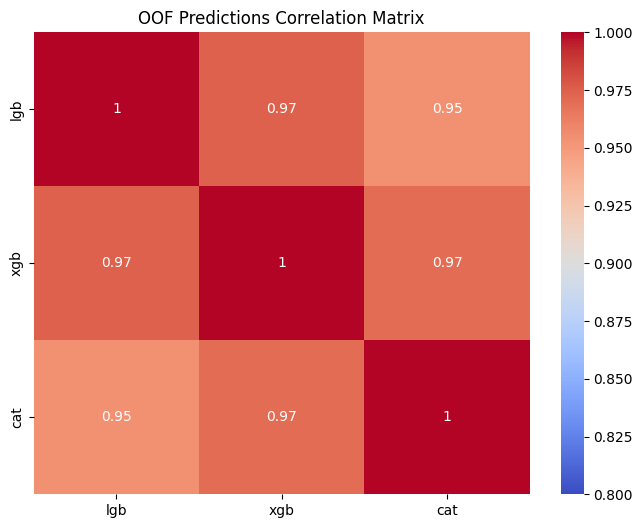


Optimizing ensemble weights using Grid Search on OOF predictions (Daily AP)...
Optimal Weights: {'lgb': 0.49, 'xgb': 0.16, 'cat': 0.35}
Optimized Ensemble Out-of-Fold Daily PR-AUC: 0.63633
submission_ensemble.csv created successfully!


In [10]:
print("Calculating OOF and Train predictions...")

def daily_average_precision(y_true, y_pred, dates):
    df = pd.DataFrame({'y_true': np.asarray(y_true), 'y_pred': np.asarray(y_pred), 'date': np.asarray(dates)})
    daily_scores = []
    for date, group in df.groupby('date'):
        if len(group['y_true'].unique()) > 1:
            score = average_precision_score(group['y_true'], group['y_pred'])
            daily_scores.append(score)
    return np.mean(daily_scores) if daily_scores else 0.0

all_possible_models = ['lgb', 'xgb', 'cat']
trained_models = []
for name in all_possible_models:
    if name in oof_preds.columns and oof_preds[name].std() > 1e-5:
        trained_models.append(name)

print(f"Active models in ensemble: {trained_models}")

for name in trained_models:
    val_pr_auc = daily_average_precision(oof_preds['target'], oof_preds[name], oof_preds['date'])
    tr_pr_auc = train_scores[name]
    if run is not None:
        wandb.log({f"{name}_oof_daily_pr_auc": val_pr_auc, f"{name}_train_daily_pr_auc": tr_pr_auc})
    print(f"[{name.upper()}] Train Daily PR-AUC: {tr_pr_auc:.5f} | Out-of-Fold Daily PR-AUC: {val_pr_auc:.5f}")

if len(trained_models) > 1:
    plt.figure(figsize=(8, 6))
    sns.heatmap(oof_preds[trained_models].corr(), annot=True, cmap='coolwarm', vmin=0.8, vmax=1.0)
    plt.title("OOF Predictions Correlation Matrix")
    plt.show()

# Прямой перебор (Grid Search) весов позволяет напрямую максимизировать целевую недифференцируемую метрику Daily AP на OOF-предсказаниях
print("\nOptimizing ensemble weights using Grid Search on OOF predictions (Daily AP)...")
best_score = 0
opt_weights = [1.0 / len(trained_models)] * len(trained_models)

if len(trained_models) == 3:
    grid_step = 100
    for w1 in range(grid_step + 1):
        for w2 in range(grid_step + 1 - w1):
            w3 = grid_step - w1 - w2
            weights = [w1/grid_step, w2/grid_step, w3/grid_step]

            pred = (weights[0] * oof_preds[trained_models[0]] +
                    weights[1] * oof_preds[trained_models[1]] +
                    weights[2] * oof_preds[trained_models[2]])
            score = daily_average_precision(oof_preds['target'], pred, oof_preds['date'])

            if score > best_score:
                best_score = score
                opt_weights = weights
else:
    print("Different model count detected. Using uniform weights.")

print(f"Optimal Weights: {dict(zip(trained_models, opt_weights))}")

opt_oof = np.zeros(len(oof_preds))
opt_test = np.zeros(len(test_preds_df))
for idx, name in enumerate(trained_models):
    opt_oof += opt_weights[idx] * oof_preds[name].values
    opt_test += opt_weights[idx] * test_preds_df[name].values

ensemble_val_pr_auc = daily_average_precision(oof_preds['target'], opt_oof, oof_preds['date'])
if run is not None:
    wandb.log({"ensemble_opt_val_daily_pr_auc": ensemble_val_pr_auc})
print(f"Optimized Ensemble Out-of-Fold Daily PR-AUC: {ensemble_val_pr_auc:.5f}")

submission = pd.DataFrame({
    "lead_id": test["lead_id"].astype(str),
    "score": opt_test
})
submission.to_csv("submission_ensemble.csv", index=False)
print("submission_ensemble.csv created successfully!")

/tmp/ipykernel_473/59987943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_473/59987943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='feature', ax=axes[i], palette='viridis')
/tmp/ipykernel_473/59987943.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feat_imp, x='importance', y='feature', ax=axes[i], palette='viridis')


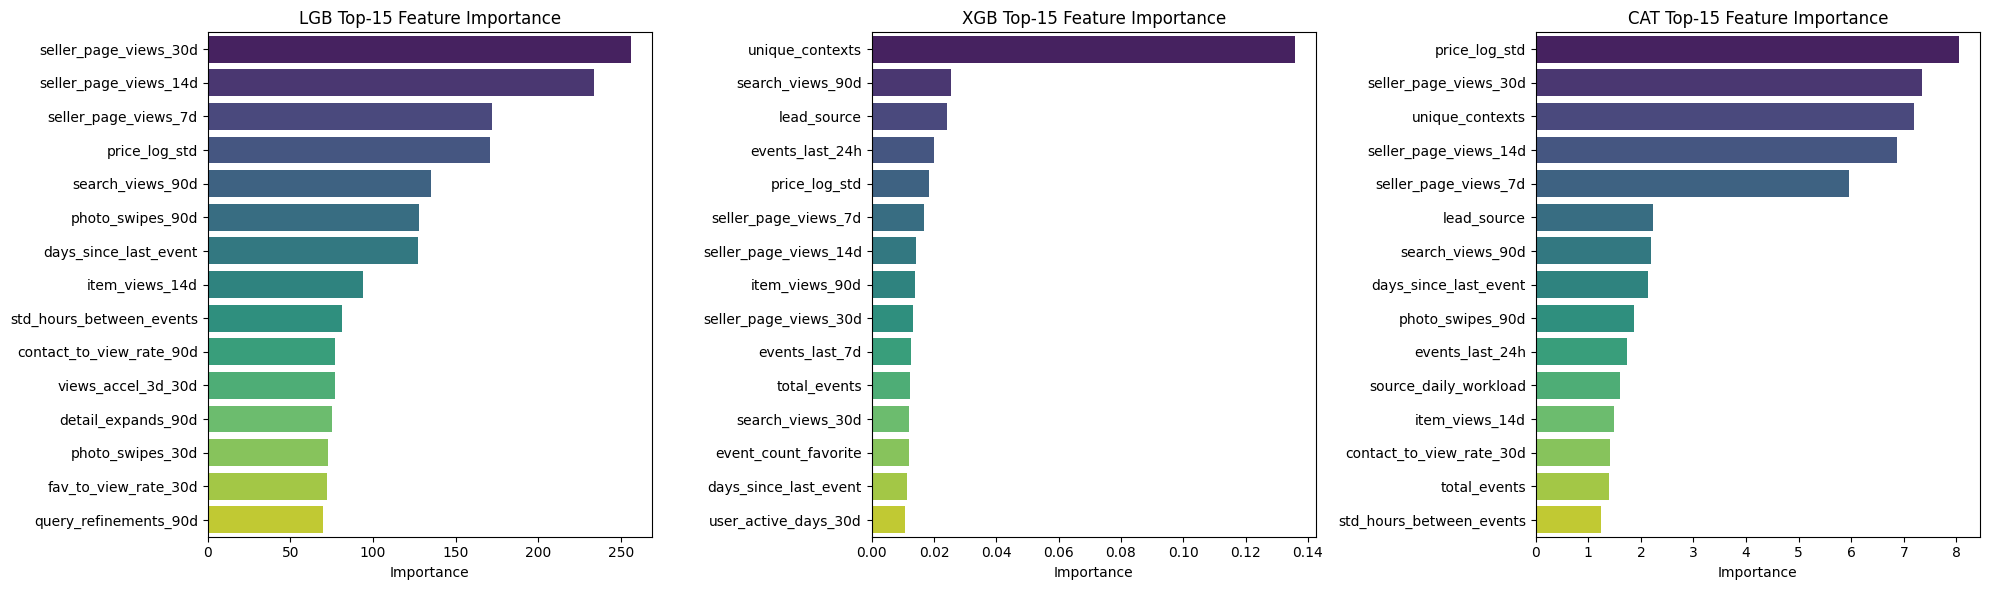

cat_oof_daily_pr_auc,▁
cat_train_daily_pr_auc,▁
ensemble_opt_val_daily_pr_auc,▁
lgb_oof_daily_pr_auc,▁
lgb_train_daily_pr_auc,▁
xgb_oof_daily_pr_auc,▁
xgb_train_daily_pr_auc,▁
cat_oof_daily_pr_auc,0.62908
cat_train_daily_pr_auc,0.78946
ensemble_opt_val_daily_pr_auc,0.63633
lgb_oof_daily_pr_auc,0.63057


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(models.items()):
    if name == 'lgb':
        importances = model.feature_importances_
    elif name == 'xgb':
        importances = model.feature_importances_
    elif name == 'cat':
        importances = model.get_feature_importance()

    feat_imp = pd.DataFrame({'feature': feature_columns, 'importance': importances})
    feat_imp = feat_imp.sort_values(by='importance', ascending=False).head(15)

    sns.barplot(data=feat_imp, x='importance', y='feature', ax=axes[i], palette='viridis')
    axes[i].set_title(f"{name.upper()} Top-15 Feature Importance")
    axes[i].set_xlabel("Importance")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

if run is not None:
    wandb.finish()

# 4. Исследованные подходы и результаты экспериментов

В процессе работы проверялись другие семейства моделей и лосс-функций, которые не вошли в итоговое решение.

### Нейросети для табличных данных (PyTorch ResNet / TabNet)
Пробовали обучать полносвязные сетки с остаточными связями (ResNet) и регуляризацией через dropout и LayerNorm.

Причины отказа:
- **Быстрое переобучение**: При 11 тысячах строк нейросеть с 150 тыс. параметров быстро запоминает обучающую выборку. AP на трейне доходил до 0.88, но на валидации скор оставался на уровне 0.48–0.51.
- **Требования к нормализации**: Нейросети чувствительны к пропускам и выбросам в таблицах, тогда как GBDT справляются с ними из коробки.

### Ранжирующие бустинги (LGBMRanker, XGBRanker)
Пробовали использовать специальные ранговые функции потерь (LambdaRank, rank:ndcg).

Причины отказа:
- **Мало групп для обучения**: Ранговые модели считают градиенты по парам внутри каждой группы (дня). В датасете всего 16 дней, а на обучающем фолде остается 12 дней. Этого объема слишком мало для построения стабильных ранговых деревьев.
- **Недообучение из-за регуляризации**: Из-за слабых градиентов ранжирования стандартные ограничения на размер листа прерывали построение деревьев (выход в пустые листья со скором ~0.47).

### Итог
Наиболее стабильный результат показал бленд трех классических бустингов (LGBM, XGBoost, CatBoost), обученных поточечно с дальнейшим подбором весов под метрику Daily AP.

In [ ]:
# Экспериментальный код обучения Tabular ResNet (PyTorch)
# Использовался для проверки работы нейросетей на табличных данных

import copy
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, QuantileTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold

# Архитектура ResNet для табличных данных
class TabularResNetBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.layernorm = nn.LayerNorm(dim)
        self.linear1 = nn.Linear(dim, dim)
        self.activation = nn.SiLU()
        self.linear2 = nn.Linear(dim, dim)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        residual = x
        x = self.layernorm(x)
        x = self.linear1(x)
        x = self.activation(x)
        x = self.dropout(x)
        x = self.linear2(x)
        x = self.dropout(x)
        return residual + x

class TabularResNet(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_blocks=2, dropout=0.3):
        super().__init__()
        self.first_linear = nn.Linear(input_dim, hidden_dim)
        self.blocks = nn.ModuleList([
            TabularResNetBlock(hidden_dim, dropout) for _ in range(num_blocks)
        ])
        self.final_norm = nn.LayerNorm(hidden_dim)
        self.activation = nn.SiLU()
        self.head = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        x = self.first_linear(x)
        for block in self.blocks:
            x = block(x)
        x = self.final_norm(x)
        x = self.activation(x)
        return self.head(x).squeeze(-1)

def eval_daily_ap(y_true, y_pred, dates):
    df = pd.DataFrame({'y_true': np.asarray(y_true), 'y_pred': np.asarray(y_pred), 'date': np.asarray(dates)})
    daily_scores = []
    for date, group in df.groupby('date'):
        if len(group['y_true'].unique()) > 1:
            score = average_precision_score(group['y_true'], group['y_pred'])
            daily_scores.append(score)
    return np.mean(daily_scores) if daily_scores else 0.0

def run_resnet_cv(X_all, y_all, groups, feature_columns, num_cols, cat_features):
    print("Initializing PyTorch Tabular ResNet training with 5-Fold GroupKFold CV...")

    gkf = GroupKFold(n_splits=5)
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"PyTorch running on device: {device}")

    # Предобработка: квантильное преобразование для числовых признаков, OHE для категориальных
    preprocessor = ColumnTransformer(
        transformers=[
            ('num', Pipeline([
                ('imputer', SimpleImputer(strategy='median')),
                ('scaler', QuantileTransformer(output_distribution='normal', random_state=42))
            ]), num_cols),
            ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_features)
        ]
    )

    resnet_oof = np.zeros(len(X_all))

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X_all, y_all, groups=groups)):
        print(f"\n--- FOLD {fold+1}/5 ---")
        X_tr, y_tr = X_all.iloc[train_idx], y_all.iloc[train_idx]
        X_va, y_va = X_all.iloc[val_idx], y_all.iloc[val_idx]

        X_tr_proc = preprocessor.fit_transform(X_tr)
        X_va_proc = preprocessor.transform(X_va)

        train_dataset = TensorDataset(
            torch.tensor(X_tr_proc, dtype=torch.float32),
            torch.tensor(y_tr.values, dtype=torch.float32)
        )
        train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True)

        input_dim = X_tr_proc.shape[1]
        model = TabularResNet(input_dim=input_dim, hidden_dim=64, num_blocks=2, dropout=0.35).to(device)
        optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2)

        best_val_ap = 0.0
        best_model_state = None

        for epoch in range(15):
            model.train()
            for X_b, y_b in train_loader:
                X_b, y_b = X_b.to(device), y_b.to(device)
                optimizer.zero_grad()
                y_pred = model(X_b)
                loss = F.binary_cross_entropy_with_logits(y_pred, y_b)
                loss.backward()
                optimizer.step()

            model.eval()
            with torch.no_grad():
                X_va_tensor = torch.tensor(X_va_proc, dtype=torch.float32).to(device)
                val_preds = torch.sigmoid(model(X_va_tensor)).cpu().numpy()
                val_ap = eval_daily_ap(y_va.values, val_preds, groups[val_idx])

                if val_ap > best_val_ap:
                    best_val_ap = val_ap
                    # Сохранение лучшей контрольной точки по метрике Daily AP
                    best_model_state = copy.deepcopy(model.state_dict())

        model.load_state_dict(best_model_state)
        model.eval()
        with torch.no_grad():
            X_va_tensor = torch.tensor(X_va_proc, dtype=torch.float32).to(device)
            resnet_oof[val_idx] = torch.sigmoid(model(X_va_tensor)).cpu().numpy()

        print(f"ResNet best Val Daily AP: {best_val_ap:.5f}")

    print("\nPyTorch Tabular ResNet trained successfully!")
    return resnet_oof

# Для запуска раскомментируйте строчку ниже:
# resnet_oof = run_resnet_cv(X_all, y_all, groups, feature_columns, num_cols, cat_features)